In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/content/drive/MyDrive/TA_SER')

FEATURES_ROOT    = PROJECT_ROOT / 'data' / 'processed' / 'features_v4'
LABEL_ENCODER_FP = PROJECT_ROOT / 'data' / 'processed' / 'label_encoder.json'
MODEL_DIR        = PROJECT_ROOT / 'saved_models' / 'v4'
REPORTS_DIR      = PROJECT_ROOT / 'reports'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE       = 32
MAX_EPOCHS       = 100
LEARNING_RATE    = 0.001
LABEL_SMOOTHING  = 0.1
L2_REG           = 0.0002
DROPOUT_CONV     = 0.25
DROPOUT_INTEGRATE= 0.35
DROPOUT_DENSE    = 0.5
PATIENCE_ES      = 15
PATIENCE_LR      = 7
LR_FACTOR        = 0.5
MIN_LR           = 1e-6

MODEL_NAME       = 'model_C'
BRANCH_FILTERS   = 64
BRANCH_KERNELS   = [3, 5, 7]
BRANCH_DILATIONS = [1, 2, 4]
INTEGRATE_FILTERS= 128
INTEGRATE_KERNEL = 3
DENSE_UNITS      = 128

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

INPUT_SHAPE = (188, 40)
NUM_CLASSES = 4

print(f'TF version: {tf.__version__}')
print(f'Model name: {MODEL_NAME} (MAIN MODEL per proposal)')
print(f'Branch kernels  : {BRANCH_KERNELS}')
print(f'Branch dilations: {BRANCH_DILATIONS}  (EXPONENTIAL — Mustaqeem 2021)')


Mounted at /content/drive
TF version: 2.19.0
Model name: model_C (MAIN MODEL per proposal)
Branch kernels  : [3, 5, 7]
Branch dilations: [1, 2, 4]  (EXPONENTIAL — Mustaqeem 2021)


In [ ]:
with open(LABEL_ENCODER_FP, 'r') as f:
    label_enc = json.load(f)

LABEL_TO_INT  = label_enc['label_to_int']
INT_TO_LABEL  = {int(k): v for k, v in label_enc['int_to_label'].items()}
TARGET_LABELS = label_enc['target_labels']

print(f'Target labels: {TARGET_LABELS}')


Target labels: ['angry', 'happy', 'neutral', 'sad']


In [ ]:
X_train = np.load(FEATURES_ROOT / 'train' / 'X_train.npy')
y_train = np.load(FEATURES_ROOT / 'train' / 'y_train.npy')
sources_train = np.load(FEATURES_ROOT / 'train' / 'sources_train.npy', allow_pickle=True)
y_train_oh = to_categorical(y_train, num_classes=NUM_CLASSES)

print(f'X_train: {X_train.shape}')

val_per_source = {}
for src in ['ravdess', 'emodb', 'tess', 'savee']:
    X_v = np.load(FEATURES_ROOT / 'val' / f'X_val_{src}.npy')
    y_v = np.load(FEATURES_ROOT / 'val' / f'y_val_{src}.npy')
    val_per_source[src] = {
        'X': X_v,
        'y': y_v,
        'y_oh': to_categorical(y_v, num_classes=NUM_CLASSES)
    }
    print(f'  val_{src}: {X_v.shape}')

X_val_combined = np.load(FEATURES_ROOT / 'val' / 'X_val_combined.npy')
y_val_combined = np.load(FEATURES_ROOT / 'val' / 'y_val_combined.npy')
y_val_combined_oh = to_categorical(y_val_combined, num_classes=NUM_CLASSES)
print(f'X_val_combined: {X_val_combined.shape}')


X_train: (9312, 188, 40)
  val_ravdess: (67, 188, 40)
  val_emodb: (34, 188, 40)
  val_tess: (160, 188, 40)
  val_savee: (30, 188, 40)
X_val_combined: (291, 188, 40)


In [ ]:
def build_branch(x, filters, kernel_size, dilation_rate, name_prefix):

    x = layers.Conv1D(
        filters, kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding='causal',  # CAUSAL untuk dilated
        kernel_regularizer=keras.regularizers.l2(L2_REG),
        name=f'{name_prefix}_conv'
    )(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn')(x)
    x = layers.Activation('relu', name=f'{name_prefix}_relu')(x)
    x = layers.Dropout(DROPOUT_CONV, name=f'{name_prefix}_drop')(x)
    x = layers.MaxPooling1D(pool_size=2, name=f'{name_prefix}_pool')(x)
    return x


def build_model_C(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):

    inputs = layers.Input(shape=input_shape, name='input')

    branches = []
    for i, (k, d) in enumerate(zip(BRANCH_KERNELS, BRANCH_DILATIONS)):
        branch = build_branch(
            inputs,
            filters=BRANCH_FILTERS,
            kernel_size=k,
            dilation_rate=d,
            name_prefix=f'branch{i+1}_k{k}_d{d}'
        )
        branches.append(branch)

    x = layers.Concatenate(axis=-1, name='concat')(branches)

    x = layers.Conv1D(
        INTEGRATE_FILTERS, kernel_size=INTEGRATE_KERNEL, padding='same',
        kernel_regularizer=keras.regularizers.l2(L2_REG),
        name='integrate_conv'
    )(x)
    x = layers.BatchNormalization(name='integrate_bn')(x)
    x = layers.Activation('relu', name='integrate_relu')(x)
    x = layers.Dropout(DROPOUT_INTEGRATE, name='integrate_drop')(x)

    x = layers.GlobalAveragePooling1D(name='gap')(x)
    x = layers.Dense(
        DENSE_UNITS, activation='relu',
        kernel_regularizer=keras.regularizers.l2(L2_REG), name='dense1'
    )(x)
    x = layers.Dropout(DROPOUT_DENSE, name='drop_dense')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return keras.Model(inputs=inputs, outputs=outputs, name=MODEL_NAME)


model = build_model_C()
model.summary()
total_params = model.count_params()
print(f'\n Total params: {total_params:,}')


Model: "model_C"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 188, 40)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_conv  │ (None, 188, 64)   │      7,744 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d2_conv  │ (None, 188, 64)   │     12,864 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d4_conv  │ (None, 188, 64)   │     17,984 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_bn    │ (None, 188, 64)   │        256 │ branch1_k3_d1_co… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d2_bn    │ (None, 188, 64)   │        256 │ branch2_k5_d2_co… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d4_bn    │ (None, 188, 64)   │        256 │ branch3_k7_d4_co… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_relu  │ (None, 188, 64)   │          0 │ branch1_k3_d1_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d2_relu  │ (None, 188, 64)   │          0 │ branch2_k5_d2_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d4_relu  │ (None, 188, 64)   │          0 │ branch3_k7_d4_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_drop  │ (None, 188, 64)   │          0 │ branch1_k3_d1_re… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d2_drop  │ (None, 188, 64)   │          0 │ branch2_k5_d2_re… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d4_drop  │ (None, 188, 64)   │          0 │ branch3_k7_d4_re… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_pool  │ (None, 94, 64)    │          0 │ branch1_k3_d1_dr… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d2_pool  │ (None, 94, 64)    │          0 │ branch2_k5_d2_dr… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d4_pool  │ (None, 94, 64)    │          0 │ branch3_k7_d4_dr… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 94, 192)   │          0 │ branch1_k3_d1_po… │
│ (Concatenate)       │                   │            │ branch2_k5_d2_po

 Total params: 130,756 (510.77 KB)

 Trainable params: 130,116 (508.27 KB)

 Non-trainable params: 640 (2.50 KB)


 Total params: 130,756


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)
print(' Model compiled')


 Model compiled


In [ ]:
class PerSourceValAccCallback(Callback):
    def __init__(self, val_per_source):
        super().__init__()
        self.val_per_source = val_per_source
        self.history_per_source = {src: [] for src in val_per_source.keys()}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        for src, data in self.val_per_source.items():
            y_pred = self.model.predict(data['X'], verbose=0)
            y_pred_class = np.argmax(y_pred, axis=1)
            acc = float(np.mean(y_pred_class == data['y']))
            self.history_per_source[src].append(acc)
            logs[f'val_acc_{src}'] = acc


per_source_callback = PerSourceValAccCallback(val_per_source)
print(' Callback initialized')


 Callback initialized


In [ ]:
checkpoint_path = MODEL_DIR / f'{MODEL_NAME}_best.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE_ES, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=PATIENCE_LR, factor=LR_FACTOR, min_lr=MIN_LR, verbose=1),
    ModelCheckpoint(filepath=str(checkpoint_path), monitor='val_loss', save_best_only=True, verbose=0),
    per_source_callback
]

print(f' Callbacks setup  | checkpoint: {checkpoint_path.name}')


 Callbacks setup  | checkpoint: model_C_best.keras


In [ ]:
history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val_combined, y_val_combined_oh),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
    shuffle=True
)

print(f'\n Training complete')
print(f' Final epoch: {len(history.history["loss"])}')
print(f' Best val_loss: {min(history.history["val_loss"]):.4f}')
print(f' Best val_acc : {max(history.history["val_accuracy"]):.4f}')


Epoch 1/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.7542 - loss: 0.9000 - val_accuracy: 0.8454 - val_loss: 0.7357 - learning_rate: 0.0010 - val_acc_ravdess: 0.5821 - val_acc_emodb: 0.7059 - val_acc_tess: 1.0000 - val_acc_savee: 0.7667
Epoch 2/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8425 - loss: 0.7503 - val_accuracy: 0.8625 - val_loss: 0.7004 - learning_rate: 0.0010 - val_acc_ravdess: 0.6716 - val_acc_emodb: 0.7059 - val_acc_tess: 1.0000 - val_acc_savee: 0.7333
Epoch 3/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8791 - loss: 0.6879 - val_accuracy: 0.8797 - val_loss: 0.6591 - learning_rate: 0.0010 - val_acc_ravdess: 0.6716 - val_acc_emodb: 0.7059 - val_acc_tess: 1.0000 - val_acc_savee: 0.9000
Epoch 4/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9049 - loss: 0.6502 - val_accuracy: 0.8763 - val_loss: 0.6670 - learning_rate: 0.0010 - val_acc_ravdess: 0.6866 - val_acc_emodb: 0.8235 - val_acc_tess: 0.9938 - val_acc_savee: 0.733

In [ ]:
full_history = dict(history.history)
full_history['val_acc_per_source'] = per_source_callback.history_per_source

def sanitize(obj):
    if isinstance(obj, dict):
        return {k: sanitize(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [sanitize(v) for v in obj]
    if isinstance(obj, (np.floating, np.integer)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

full_history_clean = sanitize(full_history)
full_history_clean['_metadata'] = {
    'model_name': MODEL_NAME,
    'is_main_model': True,
    'input_shape': list(INPUT_SHAPE),
    'num_classes': NUM_CLASSES,
    'total_params': int(total_params),
    'config': {
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'label_smoothing': LABEL_SMOOTHING,
        'l2_reg': L2_REG,
        'dropout_conv': DROPOUT_CONV,
        'dropout_integrate': DROPOUT_INTEGRATE,
        'dropout_dense': DROPOUT_DENSE,
        'branch_filters': BRANCH_FILTERS,
        'branch_kernels': BRANCH_KERNELS,
        'branch_dilations': BRANCH_DILATIONS,
        'integrate_filters': INTEGRATE_FILTERS,
    },
    'epochs_trained': len(history.history['loss']),
    'best_val_loss': float(min(history.history['val_loss'])),
    'best_val_acc': float(max(history.history['val_accuracy'])),
}

history_path = MODEL_DIR / f'history_{MODEL_NAME[-1]}.json'
with open(history_path, 'w') as f:
    json.dump(full_history_clean, f, indent=2)

print(f' History saved: {history_path}')


 History saved: /content/drive/MyDrive/TA_SER/saved_models/v4/history_C.json


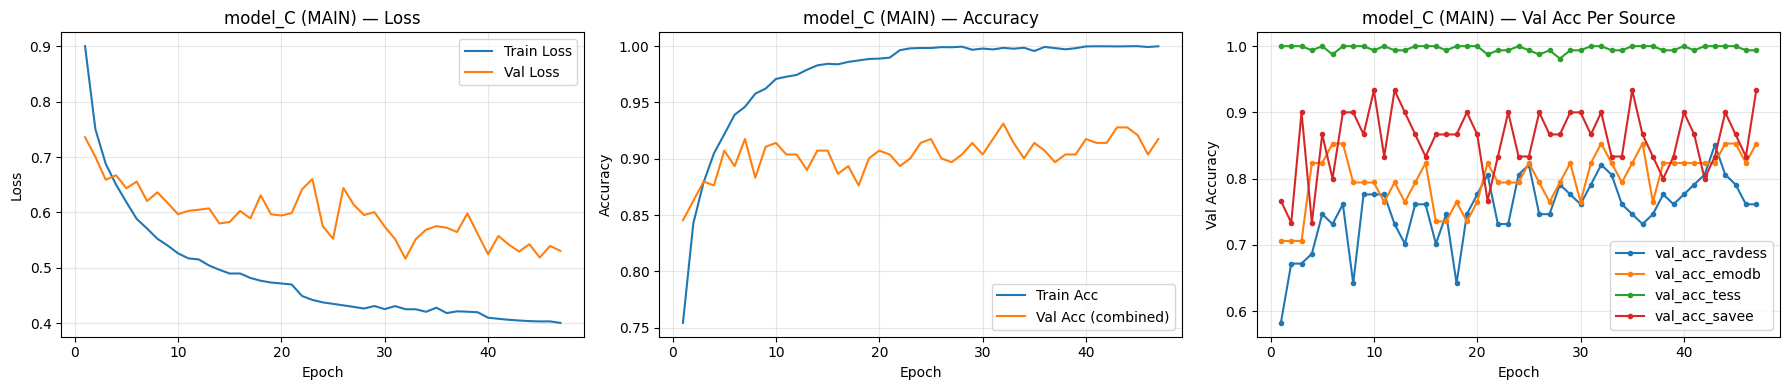

 Plot saved: /content/drive/MyDrive/TA_SER/reports/training_curves_C.png


In [ ]:
epochs = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, history.history['loss'], label='Train Loss')
axes[0].plot(epochs, history.history['val_loss'], label='Val Loss')
axes[0].set_title(f'{MODEL_NAME} (MAIN) — Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history.history['accuracy'], label='Train Acc')
axes[1].plot(epochs, history.history['val_accuracy'], label='Val Acc (combined)')
axes[1].set_title(f'{MODEL_NAME} (MAIN) — Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

for src, acc_list in per_source_callback.history_per_source.items():
    axes[2].plot(range(1, len(acc_list)+1), acc_list, label=f'val_acc_{src}', marker='.')
axes[2].set_title(f'{MODEL_NAME} (MAIN) — Val Acc Per Source')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Val Accuracy')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
curves_path = REPORTS_DIR / f'training_curves_{MODEL_NAME[-1]}.png'
plt.savefig(curves_path, dpi=100, bbox_inches='tight')
plt.show()

print(f' Plot saved: {curves_path}')


In [ ]:
print('=' * 60)
print(f'MODEL C (Multi-Branch DILATED — MAIN) — Training Summary')
print('=' * 60)
print(f'Total params          : {total_params:,}')
print(f'Epochs trained        : {len(history.history["loss"])}')
print(f'Best val_loss         : {min(history.history["val_loss"]):.4f}')
print(f'Best val_acc (combined): {max(history.history["val_accuracy"]):.4f}')
print()
print('Final val_acc per source:')
for src, acc_list in per_source_callback.history_per_source.items():
    print(f'  {src:8s}: last={acc_list[-1]:.3f}  best={max(acc_list):.3f}')

print()
print('=' * 60)
print('ABLATION COMPARISON (if A & B trained)')
print('=' * 60)
try:
    comparison = {}
    for m in ['A', 'B', 'C']:
        h_path = MODEL_DIR / f'history_{m}.json'
        if h_path.exists():
            with open(h_path, 'r') as f:
                h = json.load(f)
            comparison[m] = {
                'params': h['_metadata']['total_params'],
                'best_val_loss': h['_metadata']['best_val_loss'],
                'best_val_acc': h['_metadata']['best_val_acc'],
            }

    if comparison:
        print(f"{'Model':8s} {'Params':>10s} {'Val Loss':>10s} {'Val Acc':>10s}")
        print('-' * 42)
        for m, d in comparison.items():
            print(f"Model {m}  {d['params']:>10,} {d['best_val_loss']:>10.4f} {d['best_val_acc']:>10.4f}")
    else:
        print('Ga ada history untuk compare (training A & B dulu)')
except Exception as e:
    print(f'Comparison skipped: {e}')

print()
print(f'Checkpoint: {checkpoint_path}')
print(f'History   : {history_path}')
print(f'Plot      : {curves_path}')


MODEL C (Multi-Branch DILATED — MAIN) — Training Summary
Total params          : 130,756
Epochs trained        : 47
Best val_loss         : 0.5167
Best val_acc (combined): 0.9313

Final val_acc per source:
  ravdess : last=0.761  best=0.851
  emodb   : last=0.853  best=0.853
  tess    : last=0.994  best=1.000
  savee   : last=0.933  best=0.933

ABLATION COMPARISON (if A & B trained)
Model        Params   Val Loss    Val Acc
------------------------------------------
Model A     253,252     0.4837     0.9450
Model B     130,756     0.5214     0.9347
Model C     130,756     0.5167     0.9313

Checkpoint: /content/drive/MyDrive/TA_SER/saved_models/v4/model_C_best.keras
History   : /content/drive/MyDrive/TA_SER/saved_models/v4/history_C.json
Plot      : /content/drive/MyDrive/TA_SER/reports/training_curves_C.png
